# Effectiveness And Defense-Based Detectability

This notebook compares the paper's value selectors across:

- attack effectiveness,
- poison rate,
- random and distribution-based sampling,
- Isolation Forest, Spectral Signature, and HDBSCAN.

Poison rate is calculated from saved row counts. Folder text such as
`Poison Rate 0.3` is retained for auditing but is not treated as the
scientific rate. For example, 3,600 / 120,000 is reported as 3%.

Defense-based detectability and attack effectiveness are different
quantities. Poison recall measures whether a defense ranks poisoned
training rows as suspicious; ASR reduction measures the effect after
removal and retraining.

In [67]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = PROJECT_ROOT / "results"
MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.result_catalog import (
    DEFENSE_LABELS,
    DEFENSE_METHOD_ORDER,
    PMSB_SAMPLING_STRATEGIES,
    SAMPLING_ORDER,
    VALUE_LABELS,
    VALUE_ORDER,
    add_display_columns,
    comparison_coverage,
    discover_attack_artifacts,
    load_attack_summaries,
    load_detector_metrics,
    load_defense_metrics,
    load_detectability_score_metrics,
    load_detectability_summaries,
    merge_effectiveness,
    preferred_detector_metrics,
    preferred_defense_metrics,
)

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

PAPER_VALUE_SELECTORS = [
    "combined_shap",
    "argmin_Nv_sum_abs_shap",
    "min_population_new",
    "low_shap_signed",
    "frequency_bounded",
    "frequency_bounded_signed_shap",
    "quantile_05",
    "quantile_50",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]
PAPER_SAMPLINGS = ["random", "distribution_based_distance"]
PAPER_TARGET_FEATURES = ["problem_space_conservative"]
FOCUS_DATASETS = ["EMBER2018", "EMBER2024 WIN64"]
FOCUS_POISON_RATES = [0.01, 0.03, 0.05]

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)

Project root: /Users/falcon/Machine Learning/Defense GMM-Maha
Results root: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## Analysis Controls

Edit these lists to narrow the notebook. Leaving
The current paper matrix is fixed to 1%, 3%, and 5% poisoning.

In [68]:
def filter_paper_rows(df):
    if df.empty:
        return df.copy()
    out = df[
        df["dataset_label"].isin(FOCUS_DATASETS)
        & df["sampling_strategy"].isin(PAPER_SAMPLINGS)
        & df["value_selector"].isin(PAPER_VALUE_SELECTORS)
        & df["target_features"].isin(PAPER_TARGET_FEATURES)
    ].copy()
    if FOCUS_POISON_RATES is not None:
        wanted = np.asarray(FOCUS_POISON_RATES, dtype=float)
        out = out[
            out["poison_rate_train"].map(
                lambda value: np.isclose(value, wanted, atol=1e-12).any()
                if pd.notna(value)
                else False
            )
        ]
    return add_display_columns(out)


def ordered_pivot(df, *, index, columns, values, aggfunc="mean"):
    pivot = df.pivot_table(
        index=index,
        columns=columns,
        values=values,
        aggfunc=aggfunc,
        observed=True,
    )
    if columns in {"value_selector", "selector_label"}:
        labels = [VALUE_LABELS[value] for value in PAPER_VALUE_SELECTORS]
        pivot = pivot.reindex(columns=[label for label in labels if label in pivot.columns])
    return pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)


def show_heatmap(pivot, title, *, cmap="viridis", fmt=".1f", center=None, vmin=None, vmax=None):
    if pivot.empty:
        print("No rows for", title)
        return
    width = max(9, 0.82 * pivot.shape[1] + 2.5)
    height = max(3.2, 0.55 * pivot.shape[0] + 2.0)
    fig, ax = plt.subplots(figsize=(width, height))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Load Current Results

In [69]:
attack_df_all = load_attack_summaries(RESULTS_ROOT)
detector_df_all = load_detector_metrics(RESULTS_ROOT)
detector_df_preferred = preferred_detector_metrics(detector_df_all)
retrain_df_all = load_defense_metrics(RESULTS_ROOT)
retrain_df_preferred = preferred_defense_metrics(retrain_df_all)

attack_df = filter_paper_rows(attack_df_all)
detector_df = filter_paper_rows(detector_df_preferred)
detector_df = merge_effectiveness(detector_df, attack_df)
retrain_df = filter_paper_rows(retrain_df_preferred)

print("Attack summary rows:", len(attack_df_all), "paper rows:", len(attack_df))
print("Detector rows:", len(detector_df_all), "matched/current rows:", len(detector_df))
print("Defense retrain rows:", len(retrain_df_all), "matched/current rows:", len(retrain_df))
print("Datasets:", sorted(attack_df["dataset_label"].dropna().unique()))
print("Computed poison rates:", sorted(attack_df["poison_rate_label"].dropna().unique()))
print("Sampling strategies:", sorted(attack_df["sampling_strategy"].dropna().unique()))

Attack summary rows: 134 paper rows: 133
Detector rows: 436 matched/current rows: 396
Defense retrain rows: 170 matched/current rows: 150
Datasets: ['EMBER2018', 'EMBER2024 WIN64']
Computed poison rates: ['1%', '3%', '5%']
Sampling strategies: ['distribution_based_distance', 'random']


## Coverage And Missing Combinations

This is the first table to check after adding results. A row count of
10 means every paper value selector is present for that dataset,
poison rate, and sampling strategy.

In [70]:
attack_coverage = comparison_coverage(
    attack_df,
    datasets=FOCUS_DATASETS,
    samplings=PAPER_SAMPLINGS,
    target_features=PAPER_TARGET_FEATURES,
)
display(attack_coverage)

dataset_rates = attack_df[
    ["dataset_label", "poison_rate_label"]
].drop_duplicates()
expected = (
    dataset_rates.assign(_key=1)
    .merge(
        pd.DataFrame({"sampling_strategy": PAPER_SAMPLINGS, "_key": 1}),
        on="_key",
    )
    .merge(
        pd.DataFrame({"value_selector": PAPER_VALUE_SELECTORS, "_key": 1}),
        on="_key",
    )
    .drop(columns="_key")
)
observed = attack_df[
    ["dataset_label", "poison_rate_label", "sampling_strategy", "value_selector"]
].drop_duplicates()
missing_attack = expected.merge(observed, how="left", indicator=True)
missing_attack = missing_attack[missing_attack["_merge"] == "left_only"].drop(columns="_merge")
print("Cross-product gaps (some dataset/rate pairs were never intended for every sampling):", len(missing_attack))
display(missing_attack.head(80))

detector_coverage = (
    detector_df.groupby(
        ["dataset_label", "poison_rate_label", "sampling_strategy", "defense_method"],
        dropna=False,
    )
    .agg(
        selectors=("value_selector", "nunique"),
        mean_detector_budget_percent=("detector_removal_budget_percent", "mean"),
        mean_poison_recall_percent=("poison_recall_percent", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_label", "poison_rate_label", "defense_method"])
)
display(detector_coverage.round(3))

,dataset_label,poison_rate_label,sampling_strategy,target_features,selectors,rows,watermark_sizes
0,EMBER2018,1%,distribution_based_distance,problem_space_conservative,11,12,[17]
1,EMBER2018,1%,random,problem_space_conservative,11,11,[17]
2,EMBER2018,3%,distribution_based_distance,problem_space_conservative,11,11,[17]
3,EMBER2018,3%,random,problem_space_conservative,11,11,[17]
4,EMBER2018,5%,distribution_based_distance,problem_space_conservative,11,11,[17]
5,EMBER2018,5%,random,problem_space_conservative,11,11,[17]
6,EMBER2024 WIN64,1%,distribution_based_distance,problem_space_conservative,11,11,[19]
7,EMBER2024 WIN64,1%,random,problem_space_conservative,11,11,[19]
8,EMBER2024 WIN64,3%,distribution_based_distance,problem_space_conservative,11,11,[19]
9,EMBER2024 WIN64,3%,random,problem_space_conservative,11,11,[19]


Cross-product gaps (some dataset/rate pairs were never intended for every sampling): 0


,dataset_label,poison_rate_label,sampling_strategy,value_selector


,dataset_label,poison_rate_label,sampling_strategy,defense_method,selectors,mean_detector_budget_percent,mean_poison_recall_percent
0,EMBER2018,1%,distribution_based_distance,hdbscan,11,40.332,40.288
3,EMBER2018,1%,random,hdbscan,11,39.053,26.636
1,EMBER2018,1%,distribution_based_distance,isolation_forest,11,2.000,43.583
4,EMBER2018,1%,random,isolation_forest,11,2.000,46.508
2,EMBER2018,1%,distribution_based_distance,spectral_signature,11,2.000,14.538
5,EMBER2018,1%,random,spectral_signature,11,2.000,0.977
6,EMBER2018,3%,distribution_based_distance,hdbscan,11,35.637,43.439
9,EMBER2018,3%,random,hdbscan,11,38.287,41.475
7,EMBER2018,3%,distribution_based_distance,isolation_forest,11,6.000,40.568
10,EMBER2018,3%,random,isolation_forest,11,5.997,47.298


## Attack Effectiveness Across Sampling Strategies

These heatmaps use attack `evasions_success_percent`. They include
random and distribution-based sampling.

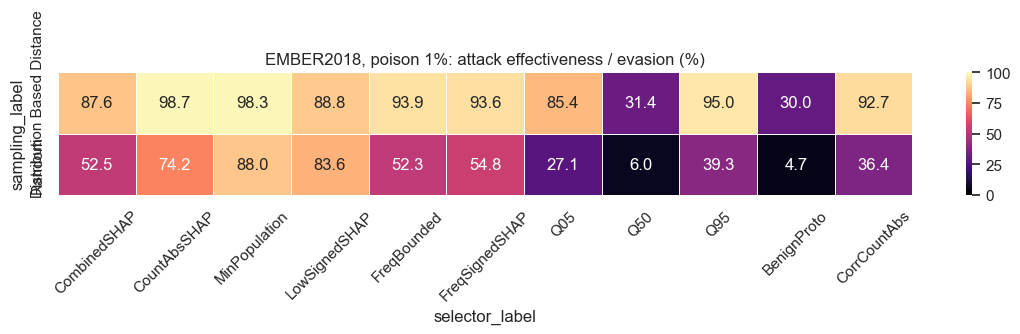

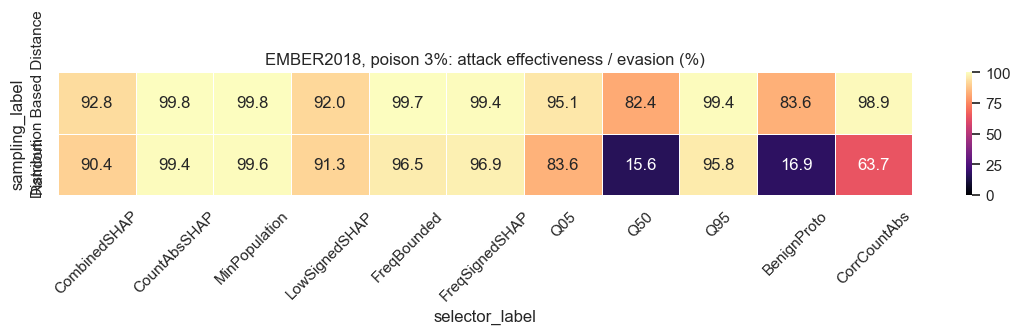

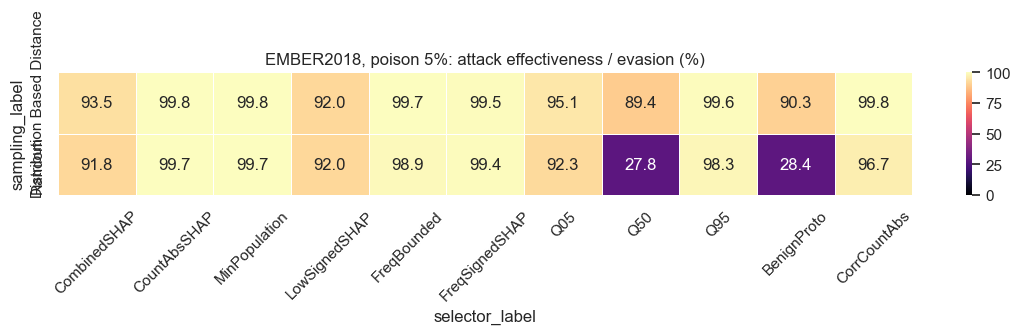

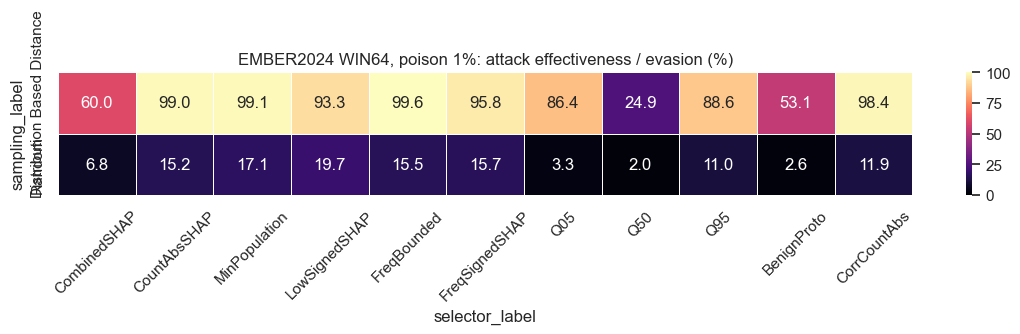

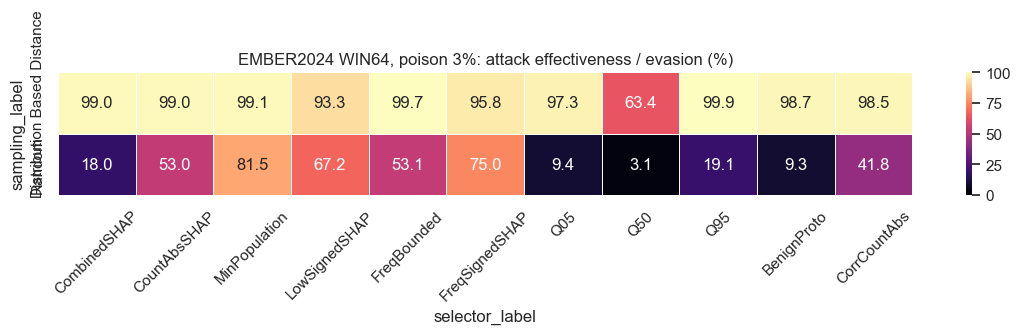

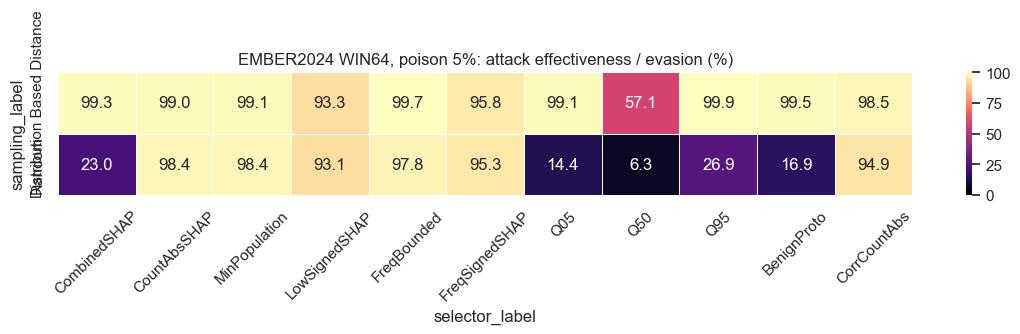

In [71]:
for (dataset, poison_label), group in attack_df.groupby(
    ["dataset_label", "poison_rate_label"], dropna=False
):
    pivot = ordered_pivot(
        group,
        index="sampling_label",
        columns="selector_label",
        values="attack_effectiveness_percent",
    )
    show_heatmap(
        pivot,
        f"{dataset}, poison {poison_label}: attack effectiveness / evasion (%)",
        cmap="magma",
        vmin=0,
        vmax=100,
    )

## Poison-Rate Comparison

A single-rate experiment appears as one point. Additional rates will
extend the same plot automatically.

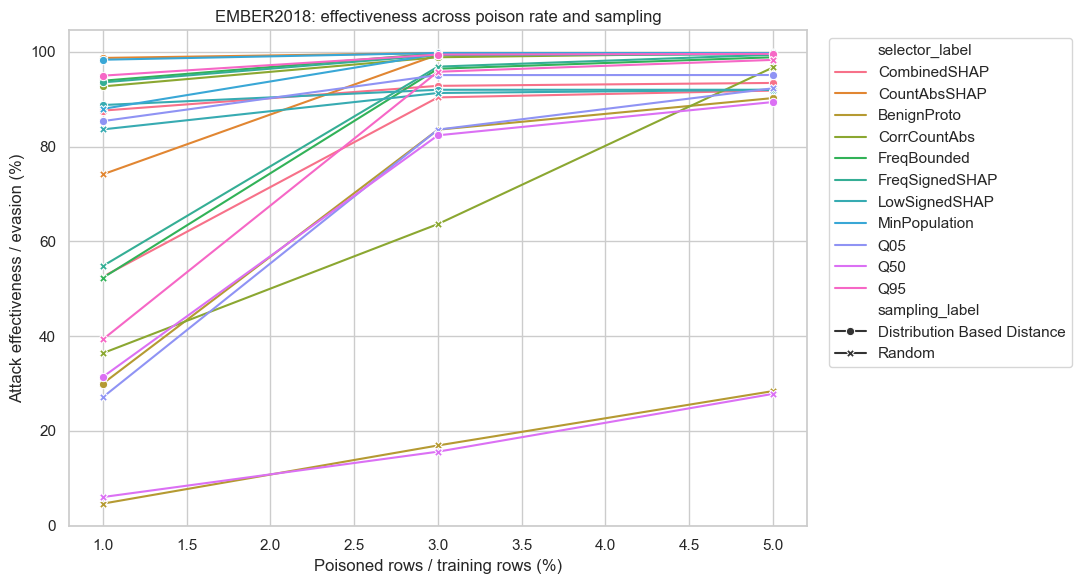

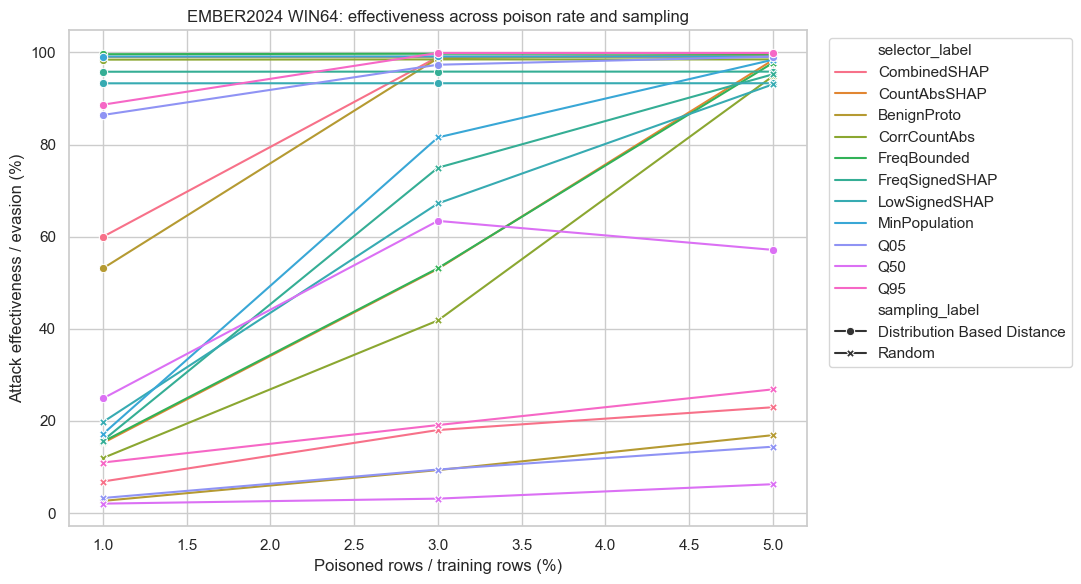

In [72]:
for dataset, group in attack_df.groupby("dataset_label"):
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.lineplot(
        data=group,
        x="poison_rate_percent",
        y="attack_effectiveness_percent",
        hue="selector_label",
        style="sampling_label",
        markers=True,
        dashes=False,
        estimator="mean",
        errorbar=None,
        ax=ax,
    )
    ax.set_title(f"{dataset}: effectiveness across poison rate and sampling")
    ax.set_xlabel("Poisoned rows / training rows (%)")
    ax.set_ylabel("Attack effectiveness / evasion (%)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Detector Results At Comparable Budgets

For Isolation Forest and Spectral Signature, the loader keeps the run
whose removal budget matches the poison prevalence in the benign-labeled
detector pool. HDBSCAN has no fixed contamination budget and is retained
as its own clustering policy. The budget columns should therefore remain
visible in paper tables.

,dataset_label,poison_rate_label,sampling_strategy,selector_label,defense_label,defense_setting,attack_effectiveness_percent,poison_recall_percent,poison_removal_precision_percent,clean_false_positive_rate_percent,detector_removal_budget_percent,removed_poisoned_rows,removed_clean_rows
141,EMBER2018,1%,random,BenignProto,HDBSCAN,hdbscan_hybrid_top32_scaled_mcs0p5pct_ms0p1pct...,4.653,30.000,1.581,38.121,37.958,360,22415
171,EMBER2018,1%,distribution_based_distance,BenignProto,HDBSCAN,hdbscan_hybrid_top32_scaled_mcs0p5pct_ms0p1pct...,29.990,36.000,1.956,36.825,36.808,432,21653
121,EMBER2018,1%,random,BenignProto,Isolation Forest,isolation_forest_hybrid_top32_scaled_contam0p02,4.653,0.083,0.083,2.039,2.000,1,1199
153,EMBER2018,1%,distribution_based_distance,BenignProto,Isolation Forest,isolation_forest_hybrid_top32_scaled_contam0p02,29.990,0.000,0.000,2.037,1.997,0,1198
131,EMBER2018,1%,random,BenignProto,Spectral Signature,spectral_signature_hybrid_top32_scaled_remove2p,4.653,0.000,0.000,2.041,2.000,0,1200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,EMBER2024 WIN64,5%,distribution_based_distance,Q95,HDBSCAN,hdbscan_hybrid_top32_scaled_mcs0p5pct_ms0p1pct...,99.883,53.654,12.624,41.262,42.501,5580,38621
319,EMBER2024 WIN64,5%,random,Q95,Isolation Forest,isolation_forest_hybrid_top32_scaled_contam0p1,26.852,29.837,29.837,7.796,10.000,3103,7297
349,EMBER2024 WIN64,5%,distribution_based_distance,Q95,Isolation Forest,isolation_forest_hybrid_top32_scaled_contam0p1,99.883,29.990,29.990,7.779,10.000,3119,7281
318,EMBER2024 WIN64,5%,random,Q95,Spectral Signature,spectral_signature_hybrid_top32_scaled_remove10p,26.852,12.163,12.163,9.760,10.000,1265,9135


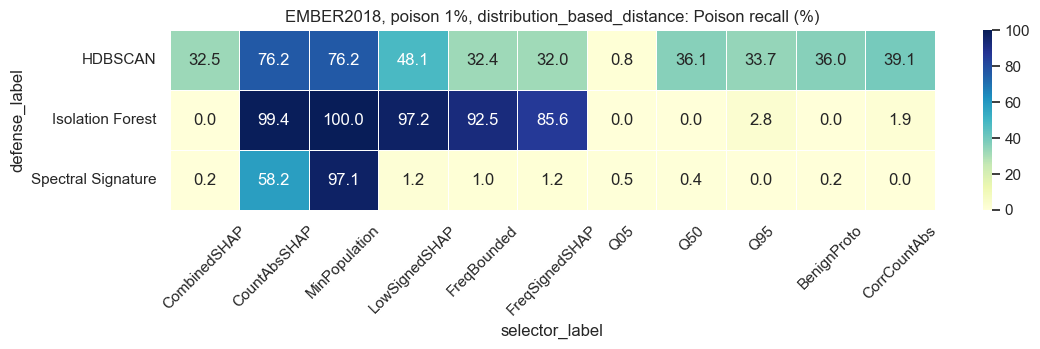

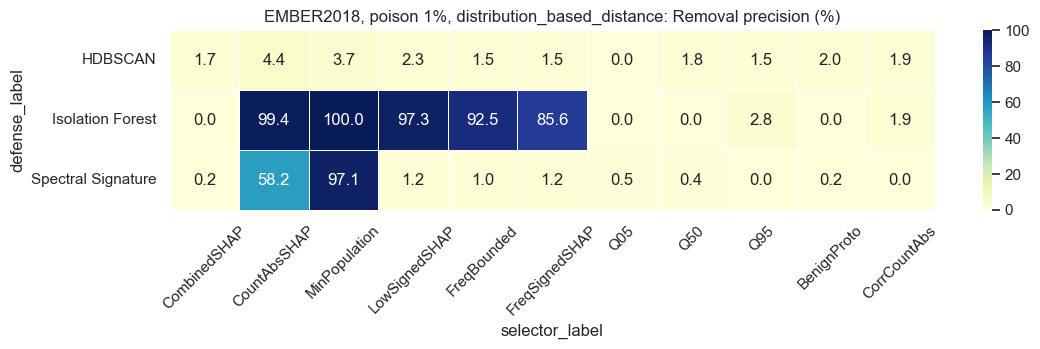

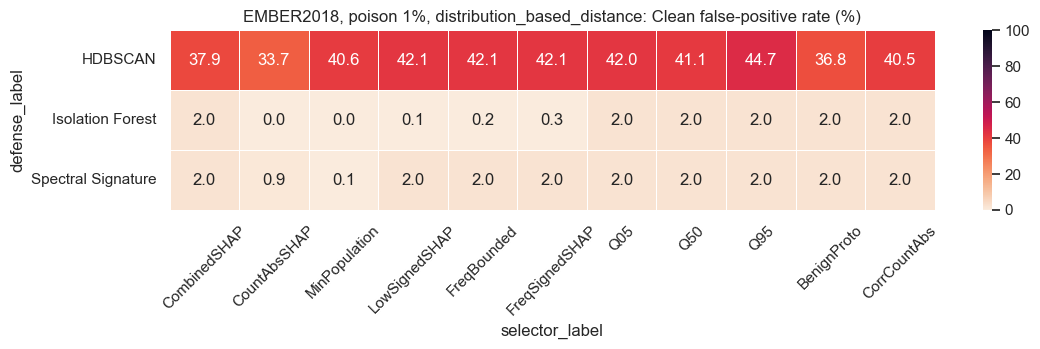

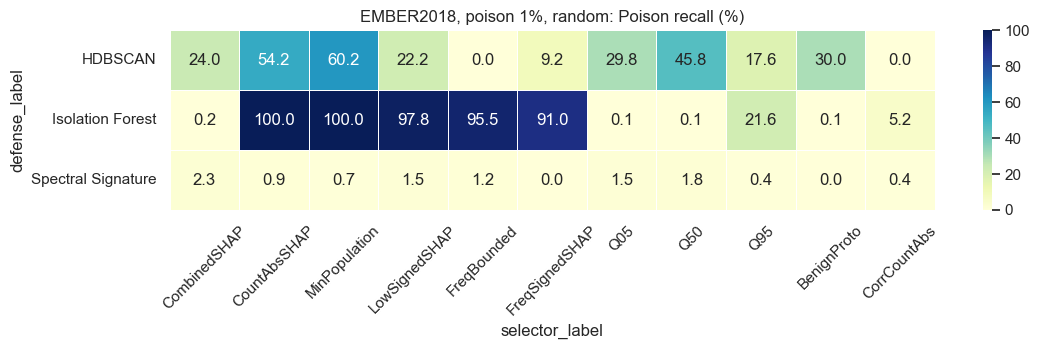

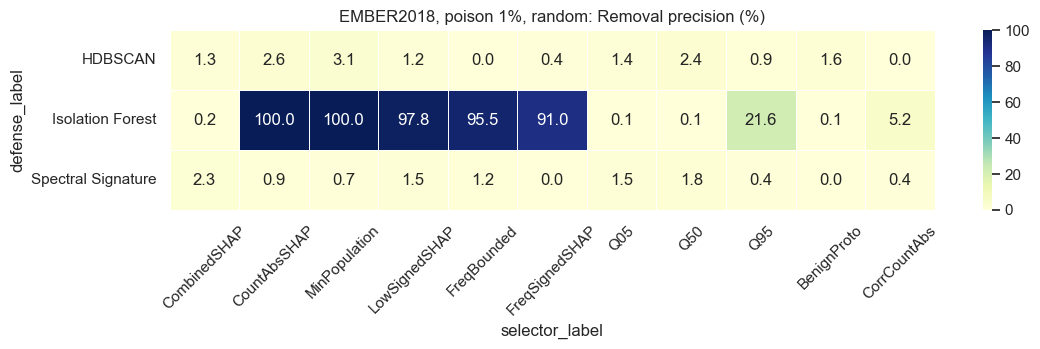

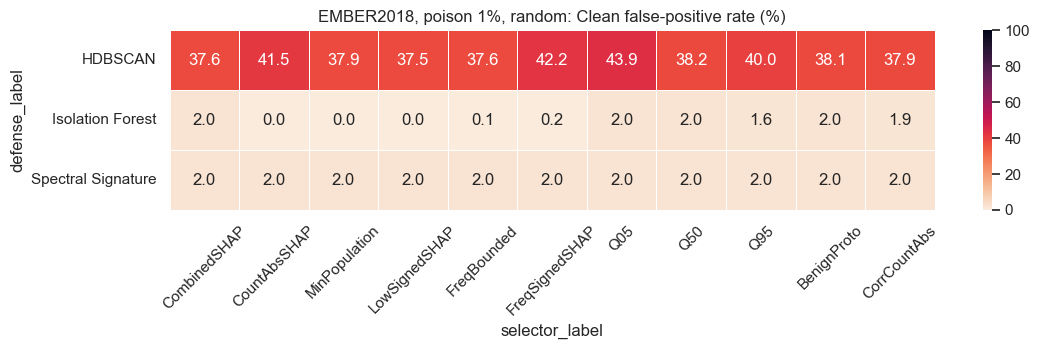

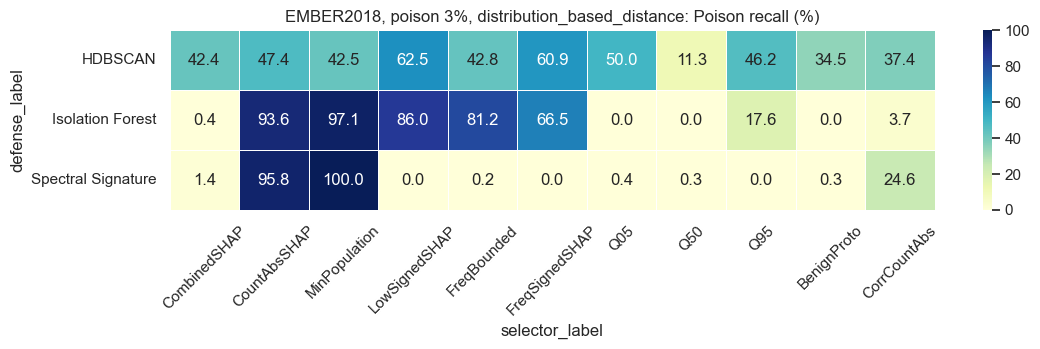

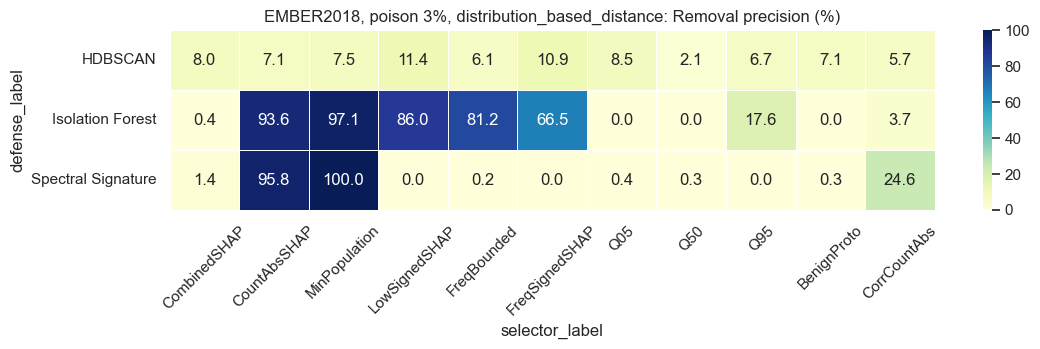

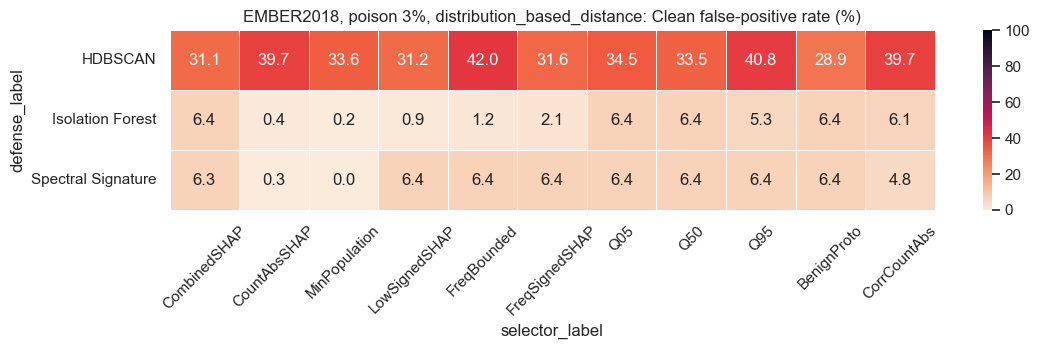

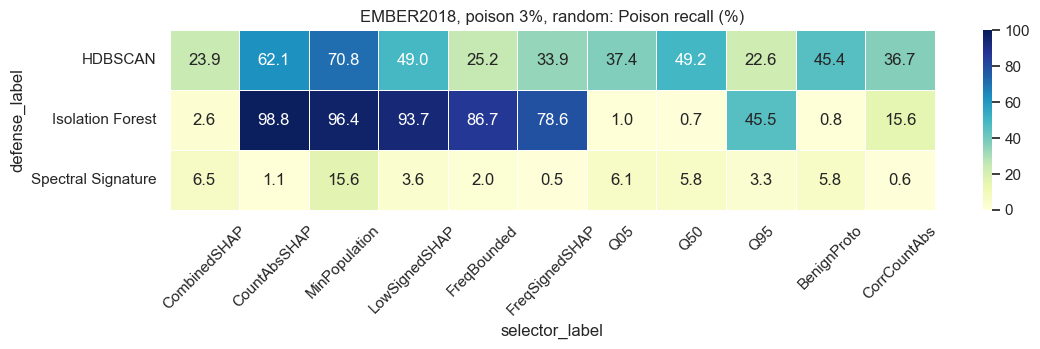

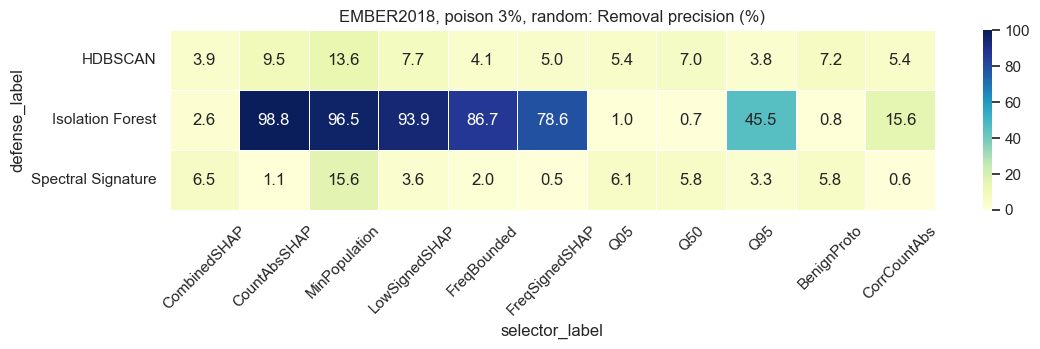

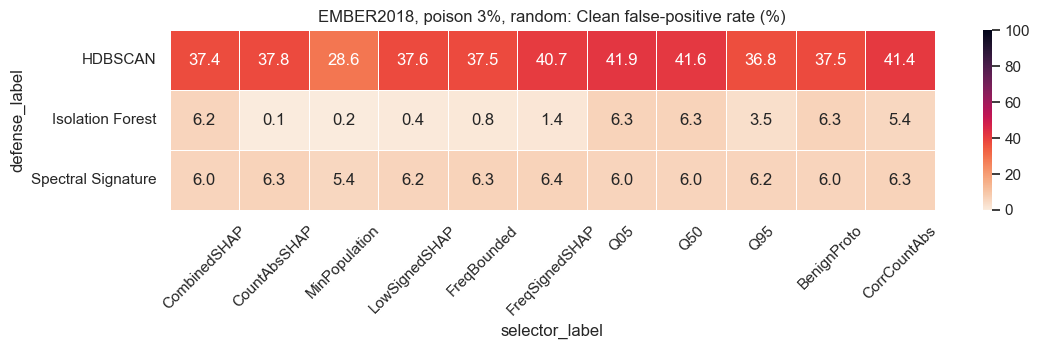

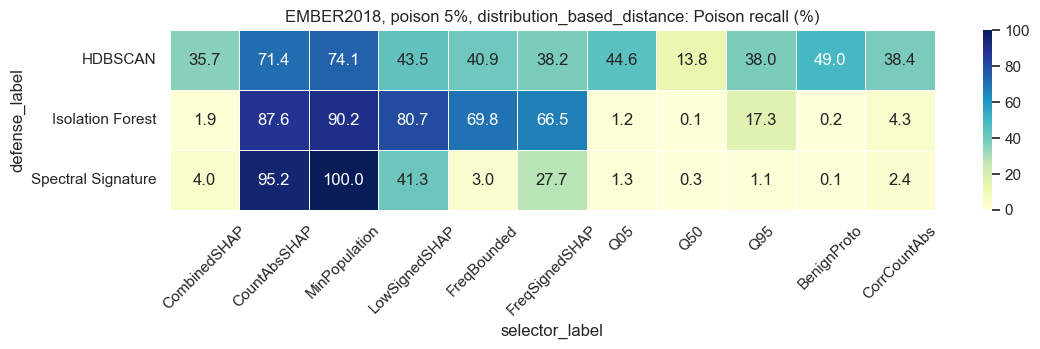

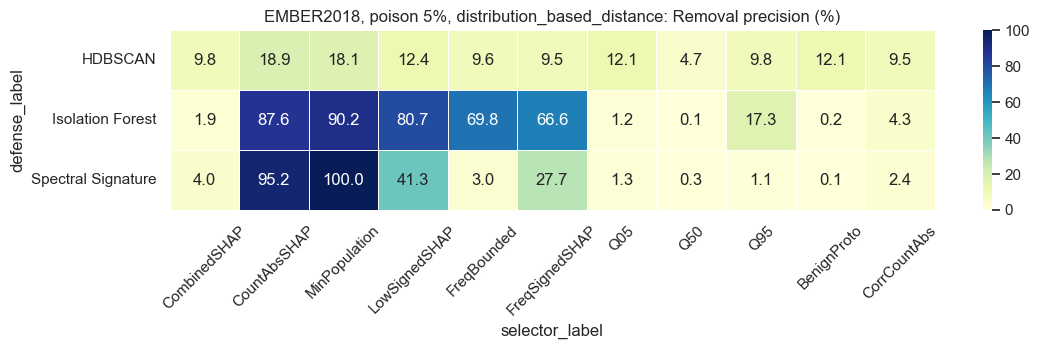

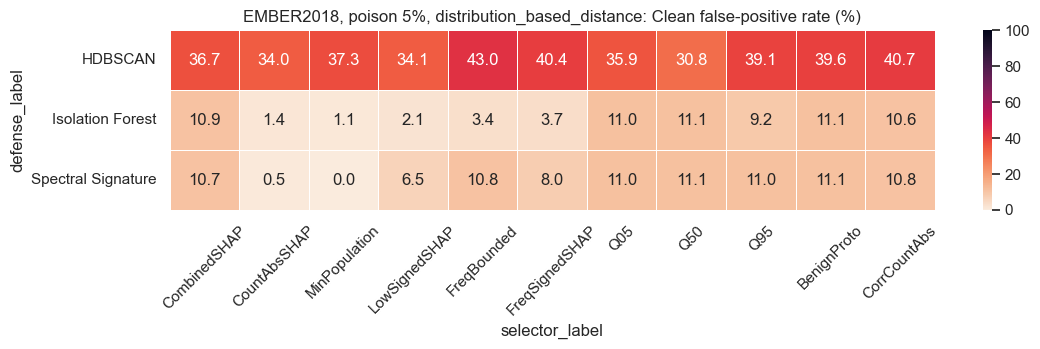

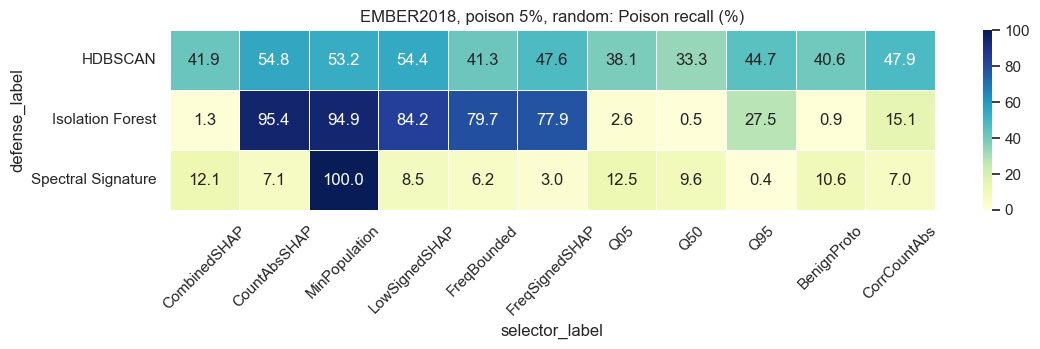

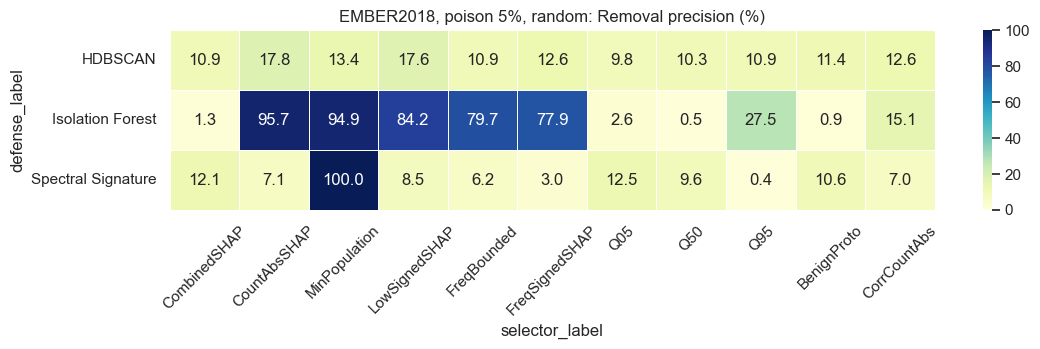

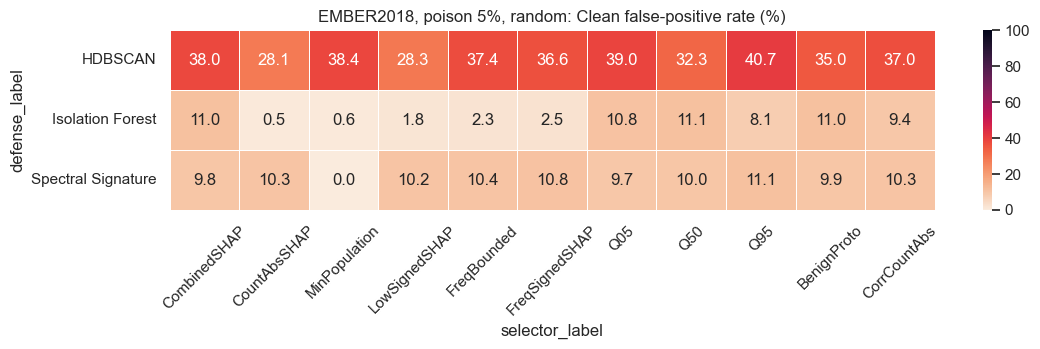

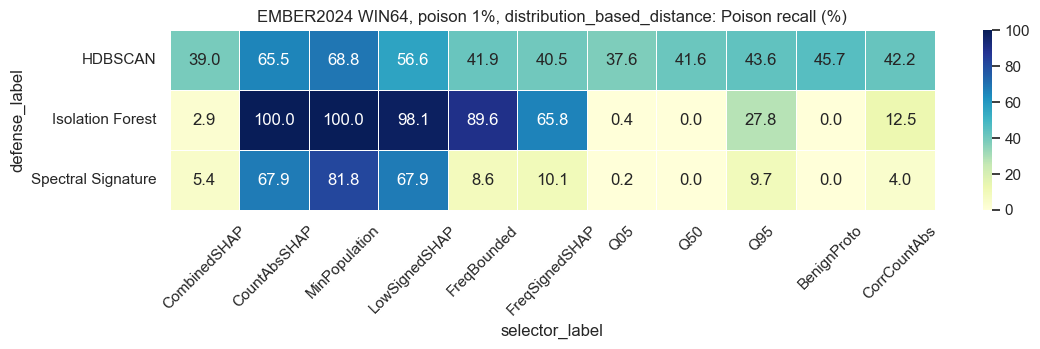

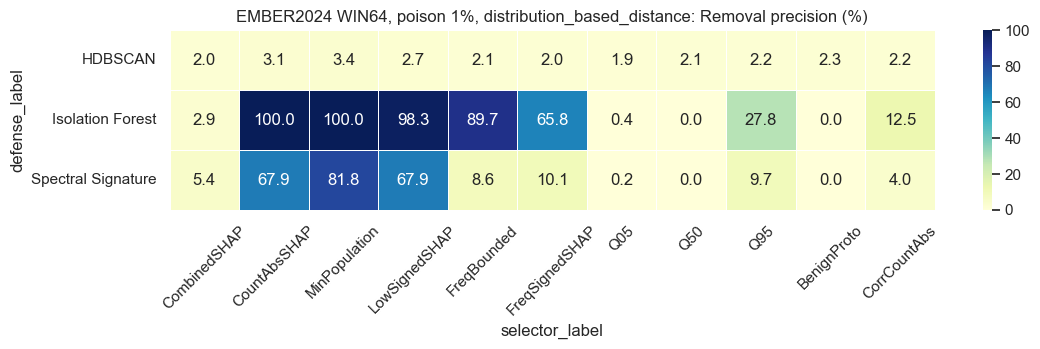

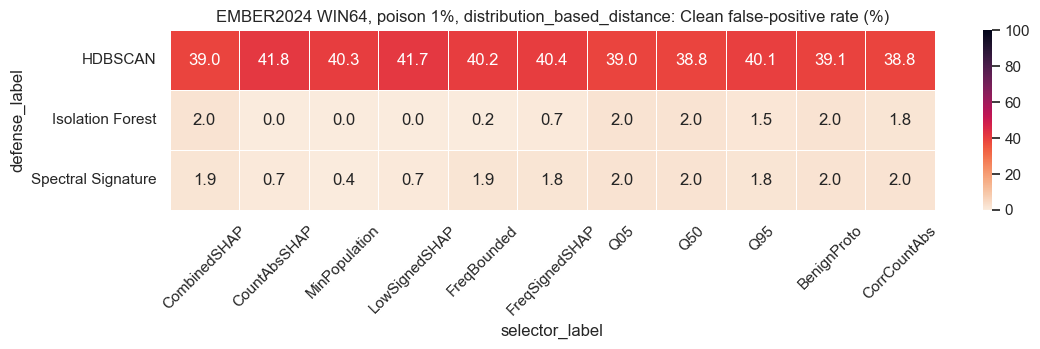

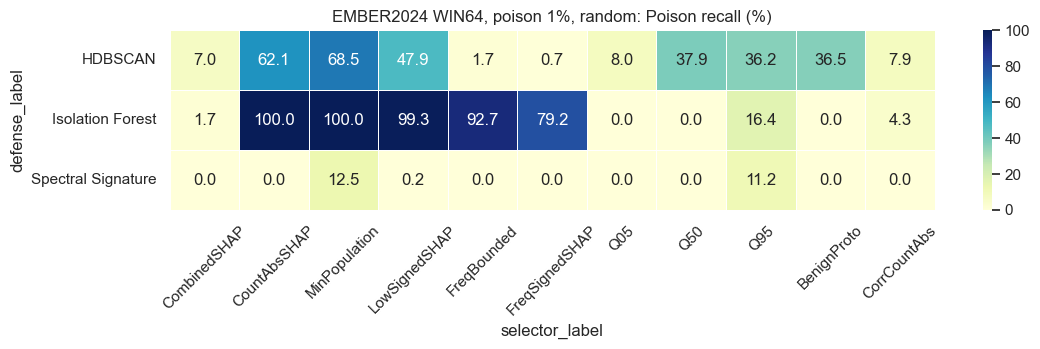

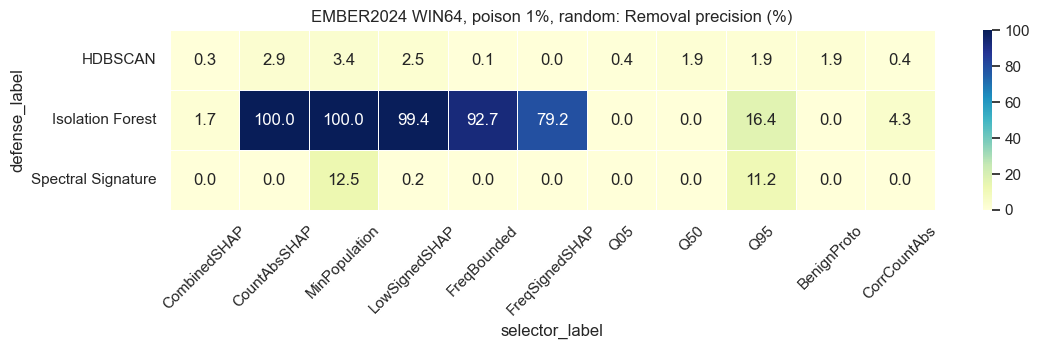

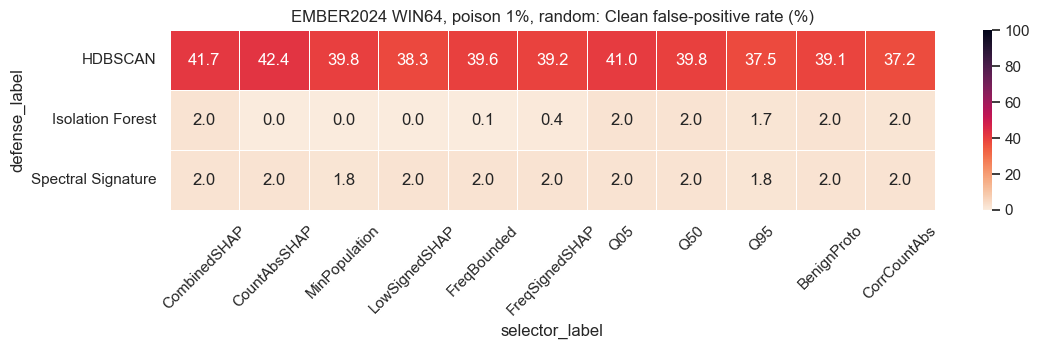

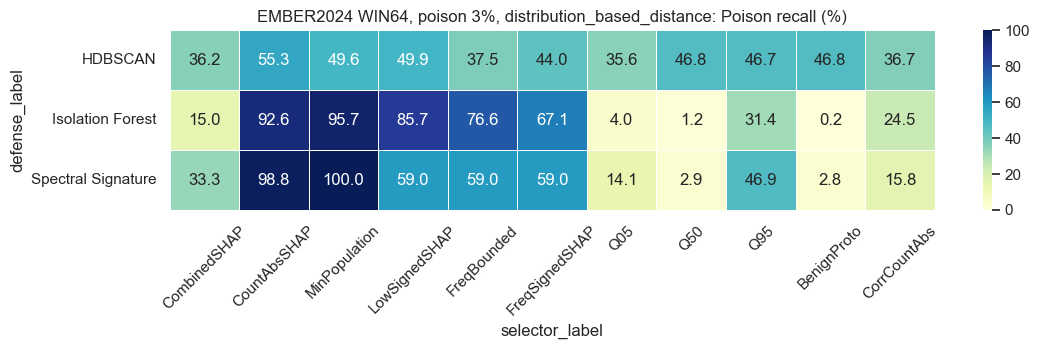

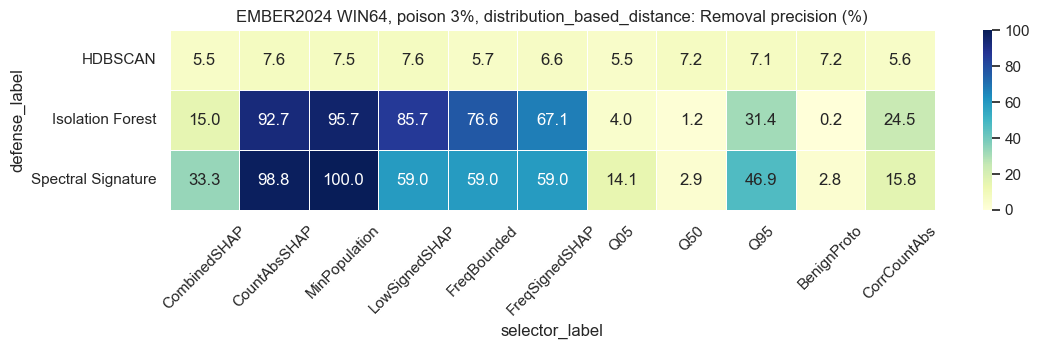

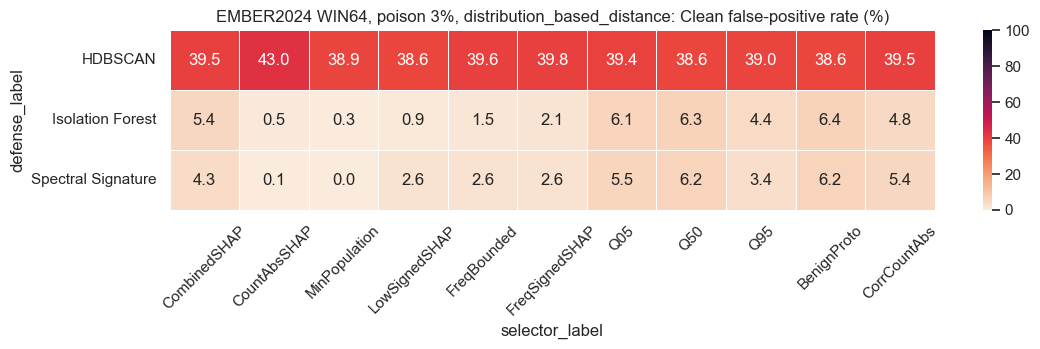

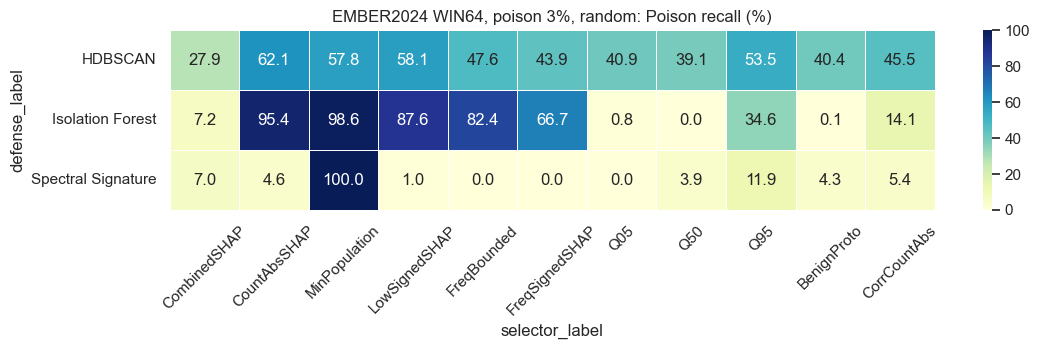

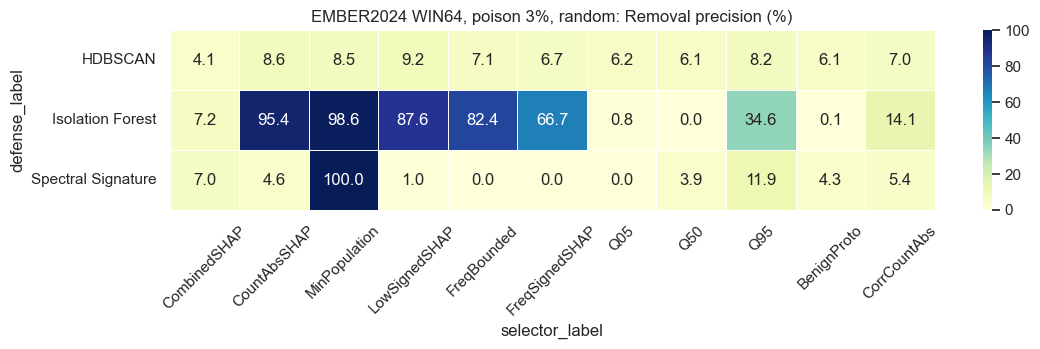

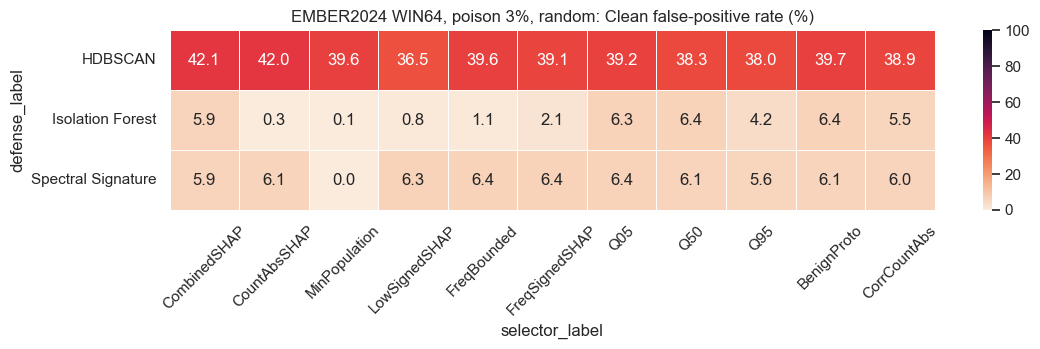

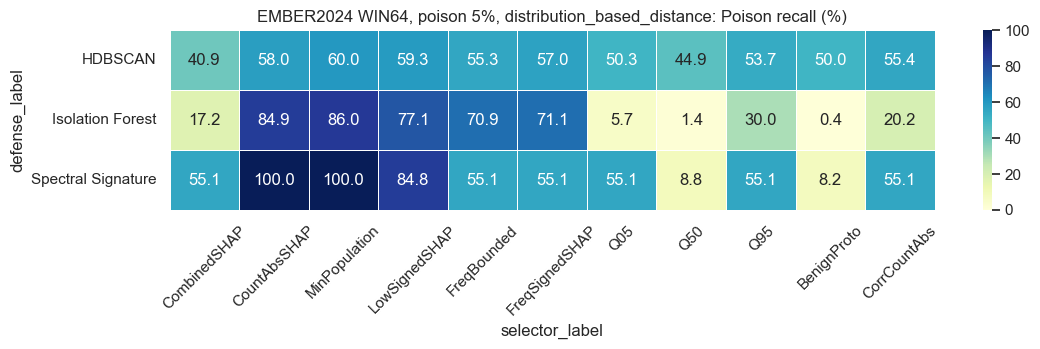

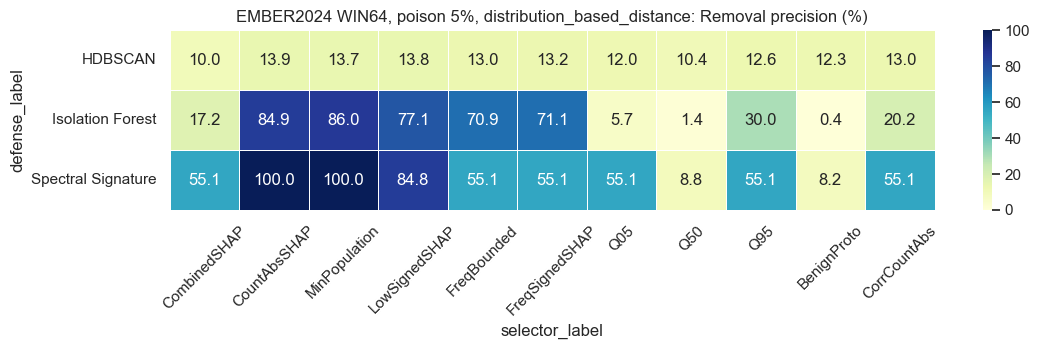

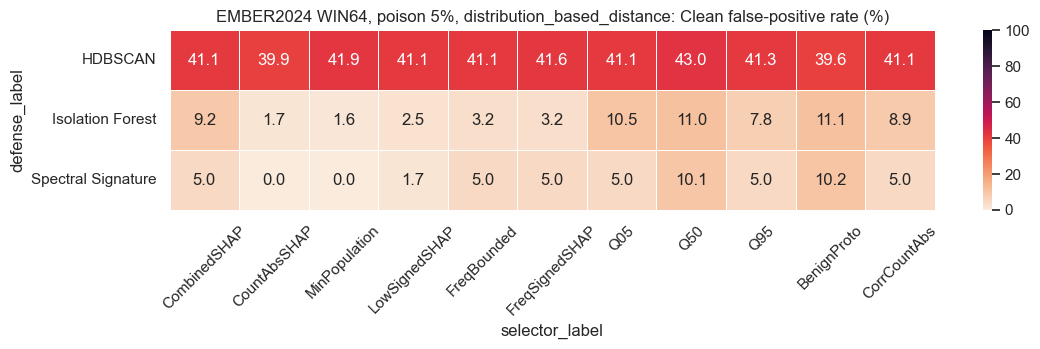

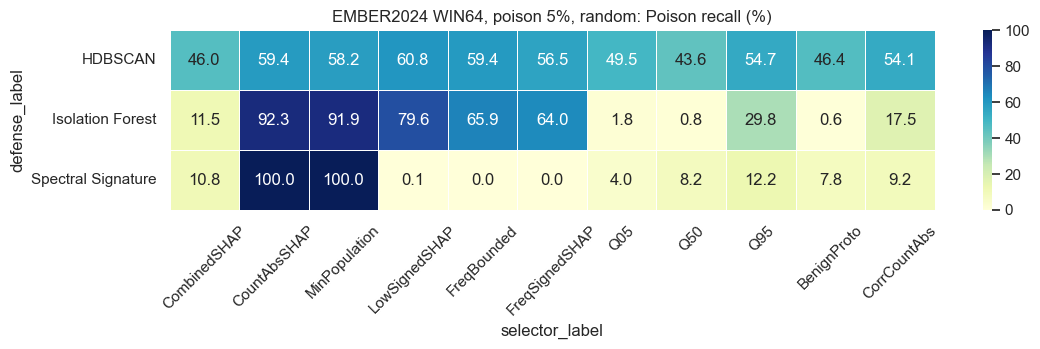

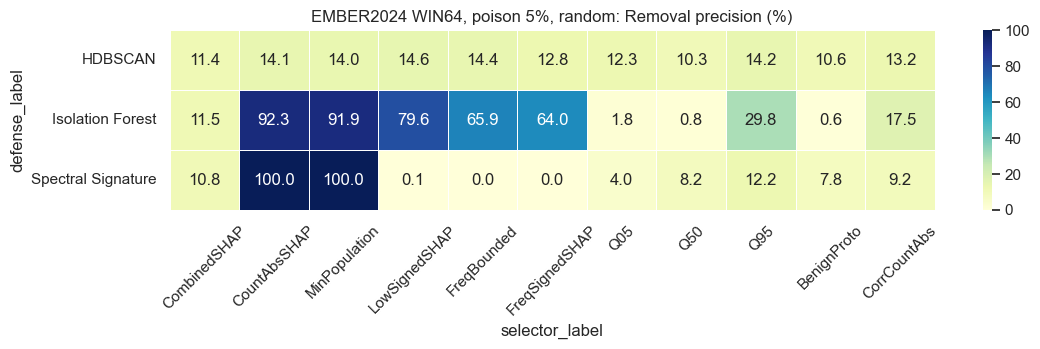

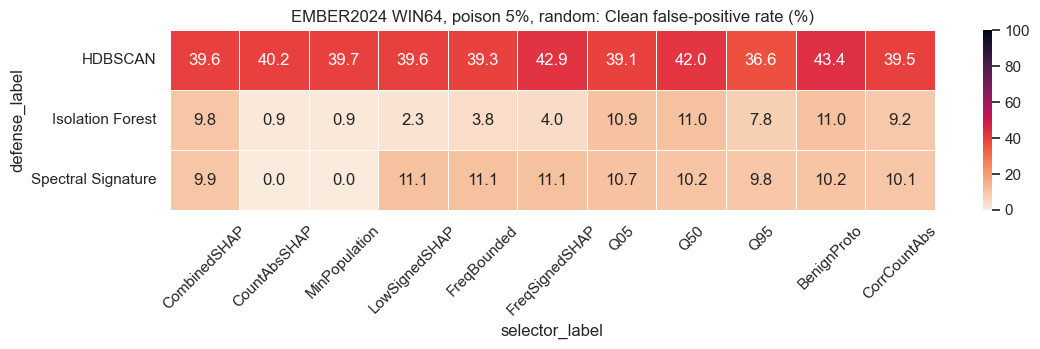

In [73]:
detector_columns = [
    "dataset_label",
    "poison_rate_label",
    "sampling_strategy",
    "selector_label",
    "defense_label",
    "defense_setting",
    "attack_effectiveness_percent",
    "poison_recall_percent",
    "poison_removal_precision_percent",
    "clean_false_positive_rate_percent",
    "detector_removal_budget_percent",
    "removed_poisoned_rows",
    "removed_clean_rows",
]
display(
    detector_df
    .sort_values(["dataset_label", "poison_rate_percent", "selector_label", "defense_label"])
    [detector_columns]
    .round(3)
)

for (dataset, poison_label, sampling), group in detector_df.groupby(
    ["dataset_label", "poison_rate_label", "sampling_strategy"], dropna=False
):
    for metric, title, cmap, center, vmin, vmax in [
        ("poison_recall_percent", "Poison recall (%)", "YlGnBu", None, 0, 100),
        ("poison_removal_precision_percent", "Removal precision (%)", "YlGnBu", None, 0, 100),
        ("clean_false_positive_rate_percent", "Clean false-positive rate (%)", "rocket_r", None, 0, 100),
    ]:
        pivot = ordered_pivot(
            group,
            index="defense_label",
            columns="selector_label",
            values=metric,
        )
        show_heatmap(
            pivot,
            f"{dataset}, poison {poison_label}, {sampling}: {title}",
            cmap=cmap,
            center=center,
            vmin=vmin,
            vmax=vmax,
        )

## Effectiveness Versus Defense Detectability

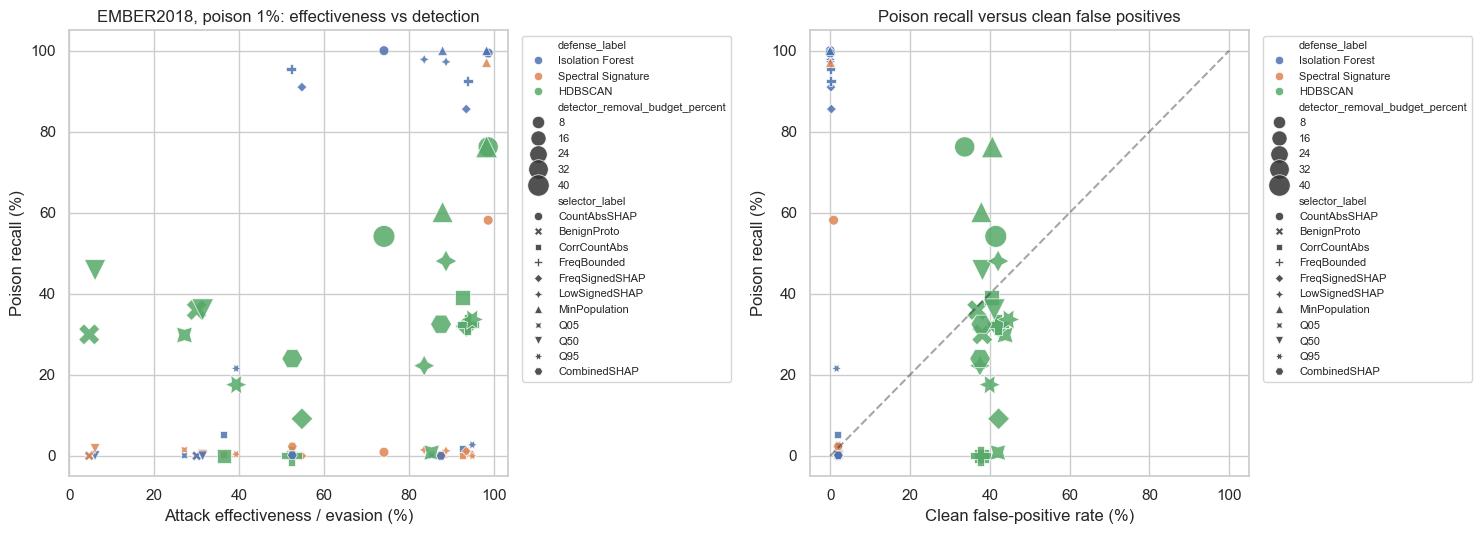

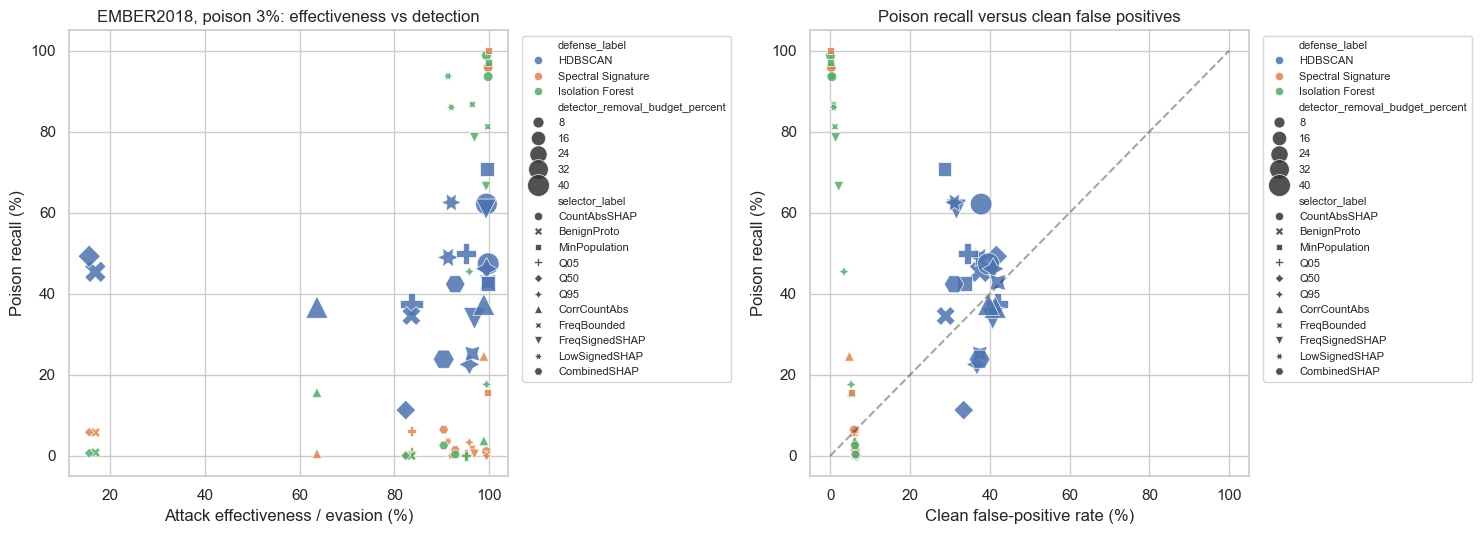

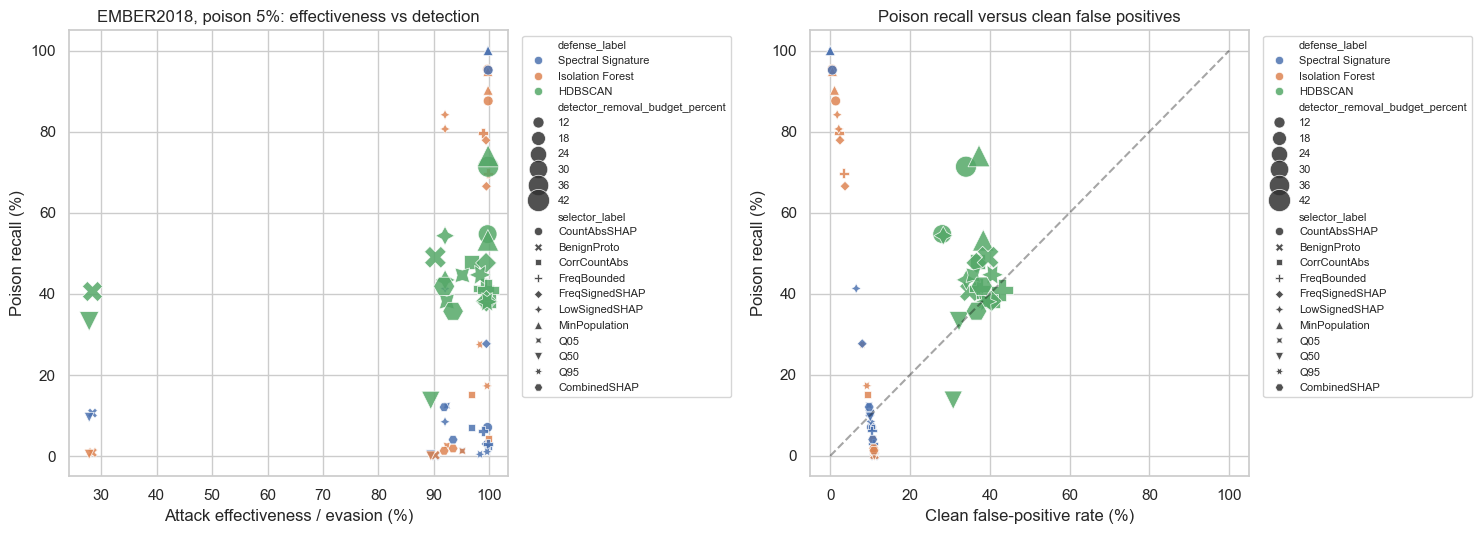

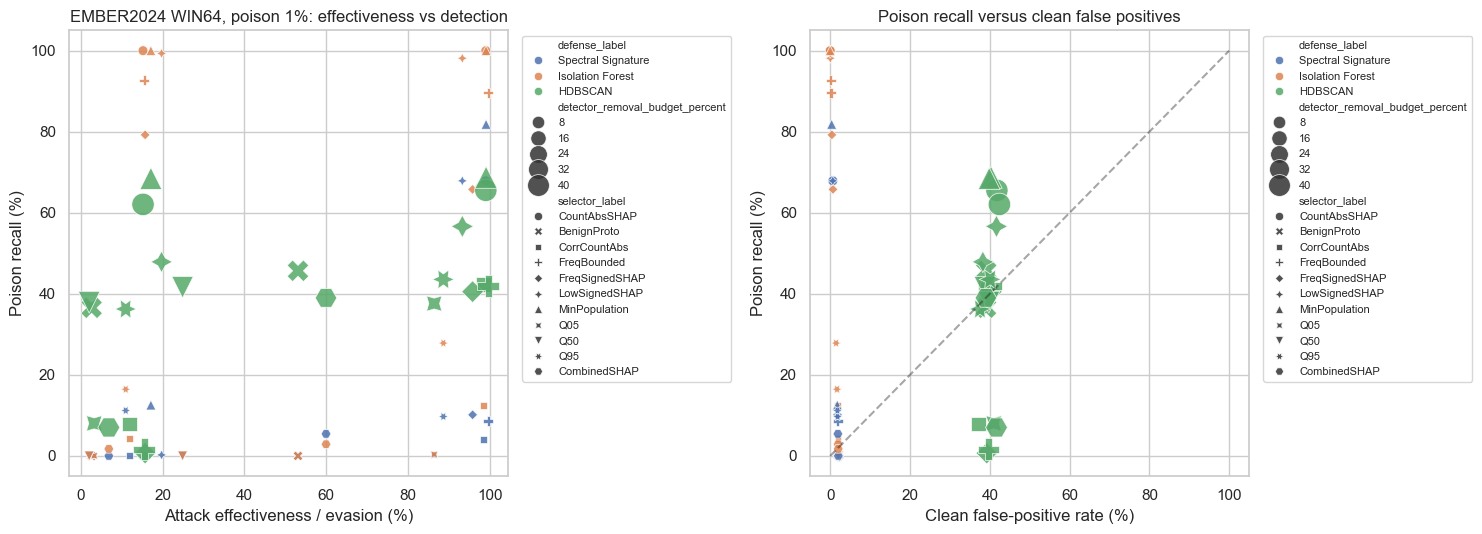

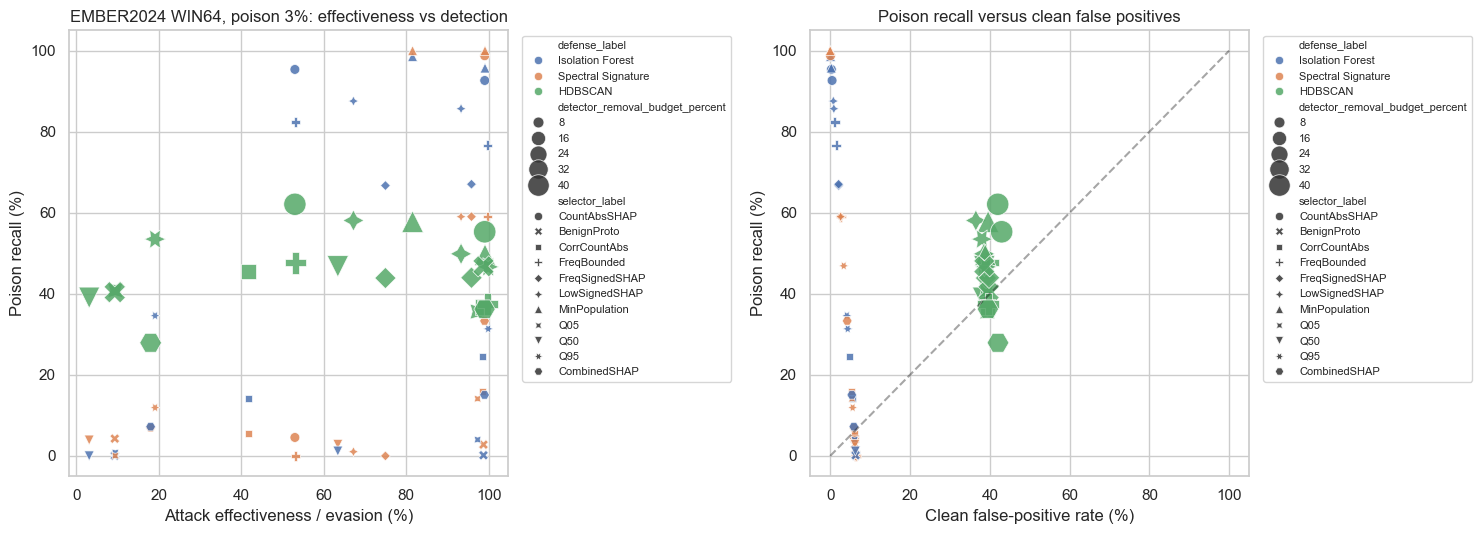

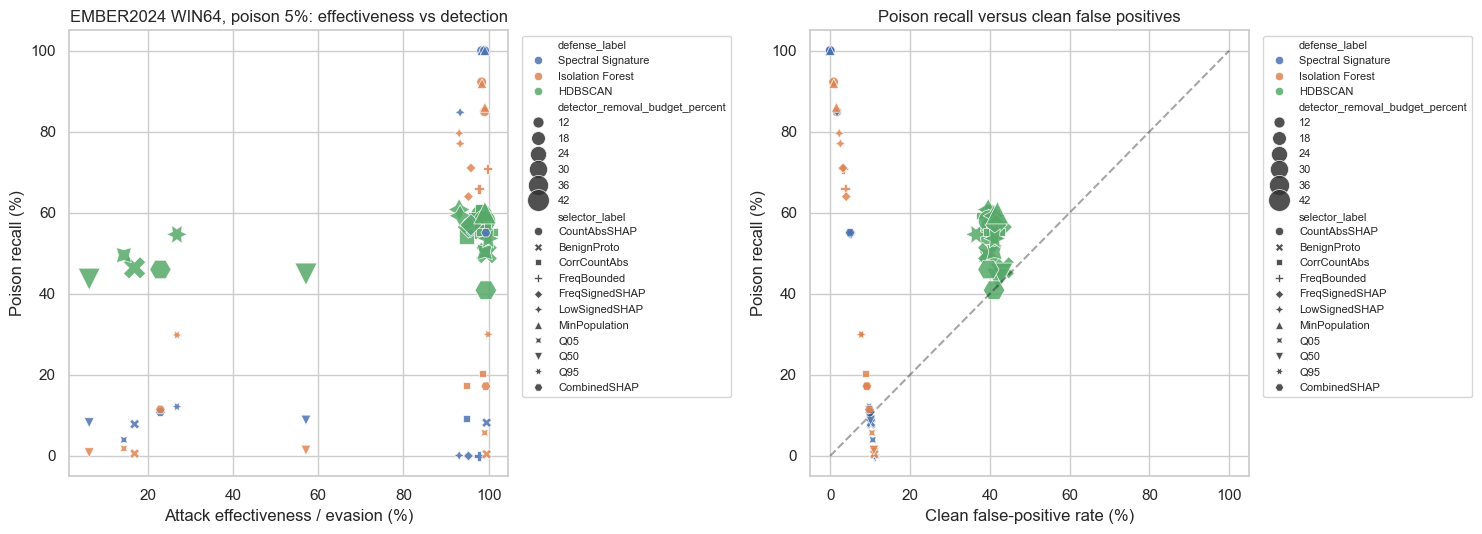

In [74]:
for (dataset, poison_label), group in detector_df.groupby(
    ["dataset_label", "poison_rate_label"], dropna=False
):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.scatterplot(
        data=group,
        x="attack_effectiveness_percent",
        y="poison_recall_percent",
        hue="defense_label",
        style="selector_label",
        size="detector_removal_budget_percent",
        sizes=(50, 260),
        alpha=0.85,
        ax=axes[0],
    )
    axes[0].set_title(f"{dataset}, poison {poison_label}: effectiveness vs detection")
    axes[0].set_xlabel("Attack effectiveness / evasion (%)")
    axes[0].set_ylabel("Poison recall (%)")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    sns.scatterplot(
        data=group,
        x="clean_false_positive_rate_percent",
        y="poison_recall_percent",
        hue="defense_label",
        style="selector_label",
        size="detector_removal_budget_percent",
        sizes=(50, 260),
        alpha=0.85,
        ax=axes[1],
    )
    axes[1].plot([0, 100], [0, 100], linestyle="--", color="black", alpha=0.35)
    axes[1].set_title("Poison recall versus clean false positives")
    axes[1].set_xlabel("Clean false-positive rate (%)")
    axes[1].set_ylabel("Poison recall (%)")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

## Optional Mitigation After Retraining

Most recent experiments intentionally stop after detection. This section
shows ASR reduction and clean-accuracy cost only for configurations that
already have defended retraining outputs; missing rows are not treated as
defense failures.

In [75]:
if retrain_df.empty:
    print("No matching retraining outputs are available.")
else:
    retrain_columns = [
        "dataset_label",
        "poison_rate_label",
        "sampling_strategy",
        "selector_label",
        "defense_label",
        "backdoored_asr_percent",
        "defended_asr_percent",
        "asr_reduction_pp",
        "clean_accuracy_delta_pp",
    ]
    display(
        retrain_df
        .sort_values(["dataset_label", "poison_rate_percent", "selector_label", "defense_label"])
        [retrain_columns]
        .round(3)
    )

,dataset_label,poison_rate_label,sampling_strategy,selector_label,defense_label,backdoored_asr_percent,defended_asr_percent,asr_reduction_pp,clean_accuracy_delta_pp
125,EMBER2018,1%,random,BenignProto,HDBSCAN,7.745,8.610,-0.865,-0.753
123,EMBER2018,1%,random,BenignProto,Isolation Forest,7.745,10.438,-2.693,-0.034
124,EMBER2018,1%,random,BenignProto,Spectral Signature,7.745,8.308,-0.563,-0.050
128,EMBER2018,1%,random,CorrCountAbs,HDBSCAN,36.628,40.036,-3.408,-0.598
126,EMBER2018,1%,random,CorrCountAbs,Isolation Forest,36.628,30.347,6.281,-0.196
127,EMBER2018,1%,random,CorrCountAbs,Spectral Signature,36.628,29.086,7.543,-0.163
122,EMBER2018,1%,random,CountAbsSHAP,HDBSCAN,74.378,60.525,13.852,-0.721
120,EMBER2018,1%,random,CountAbsSHAP,Isolation Forest,74.378,2.699,71.679,-0.145
121,EMBER2018,1%,random,CountAbsSHAP,Spectral Signature,74.378,68.647,5.731,-0.065
131,EMBER2018,1%,random,FreqBounded,HDBSCAN,52.581,61.847,-9.266,-0.761


## Selector-Level Paper Table

In [76]:
selector_summary = (
    detector_df.groupby(
        ["dataset_label", "poison_rate_label", "sampling_strategy", "value_selector", "selector_label"],
        observed=True,
    )
    .agg(
        attack_effectiveness_percent=("attack_effectiveness_percent", "mean"),
        mean_poison_recall_percent=("poison_recall_percent", "mean"),
        mean_removal_precision_percent=("poison_removal_precision_percent", "mean"),
        mean_clean_false_positive_rate_percent=("clean_false_positive_rate_percent", "mean"),
        max_clean_rows_removed=("removed_clean_rows", "max"),
        defense_methods=("defense_method", "nunique"),
    )
    .reset_index()
    .sort_values(["dataset_label", "poison_rate_label", "attack_effectiveness_percent"], ascending=[True, True, False])
)
display(selector_summary.round(3))

,dataset_label,poison_rate_label,sampling_strategy,value_selector,selector_label,attack_effectiveness_percent,mean_poison_recall_percent,mean_removal_precision_percent,mean_clean_false_positive_rate_percent,max_clean_rows_removed,defense_methods
0,EMBER2018,1%,distribution_based_distance,argmin_Nv_sum_abs_shap,CountAbsSHAP,98.729,77.944,53.999,11.526,19823,3
7,EMBER2018,1%,distribution_based_distance,min_population_new,MinPopulation,98.350,91.111,66.924,13.565,23894,3
10,EMBER2018,1%,distribution_based_distance,quantile_95,Q95,94.988,12.139,1.421,16.240,26280,3
4,EMBER2018,1%,distribution_based_distance,frequency_bounded,FreqBounded,93.916,41.972,31.683,14.745,24732,3
5,EMBER2018,1%,distribution_based_distance,frequency_bounded_signed_shap,FreqSignedSHAP,93.571,39.583,29.426,14.796,24741,3
3,EMBER2018,1%,distribution_based_distance,corr_count_abs_shap,CorrCountAbs,92.720,13.667,1.283,14.850,23819,3
6,EMBER2018,1%,distribution_based_distance,low_shap_signed,LowSignedSHAP,88.787,48.861,33.620,14.715,24740,3
18,EMBER2018,1%,random,min_population_new,MinPopulation,87.977,53.611,34.602,13.303,22275,3
2,EMBER2018,1%,distribution_based_distance,combined_shap,CombinedSHAP,87.613,10.889,0.629,13.991,22282,3
8,EMBER2018,1%,distribution_based_distance,quantile_05,Q05,85.394,0.444,0.180,15.370,24719,3


## Optional Export

In [77]:
SAVE_TABLES = False
if SAVE_TABLES:
    out_dir = RESULTS_ROOT / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    attack_df.to_csv(out_dir / "paper_attack_effectiveness_catalog.csv", index=False)
    detector_df.to_csv(out_dir / "paper_defense_detectability_catalog.csv", index=False)
    retrain_df.to_csv(out_dir / "paper_defense_retraining_catalog.csv", index=False)
    selector_summary.to_csv(out_dir / "paper_selector_defense_summary.csv", index=False)
    print("Saved tables to", out_dir)
else:
    print("SAVE_TABLES is False; no files written.")

SAVE_TABLES is False; no files written.
